In [ ]:
from lib.oracle import run_oracle, safe_run_oracle
from lib.explorer import explore_points, explore_points_parallel
from lib.utils import estimate_exploration_time, expand_parameter_space
import numpy as np
import pandas as pd

parameter_space = {
    "lambda6":    {"min": -1,    "max": 1,      "step": 0.34273},
    "lambda7":    {"min": -1,    "max": 1,      "step": 0.34273},
    "m12":{"min": -1,    "max": 1,      "step": 0.434273},
    "alpha":      {"min": -0.7, "max": 0.7,   "step": 0.35},
    "beta":       {"min": 0.5, "max": np.pi/2, "step": np.pi/36},
    "m_phi":       {"min": 125,   "max": 400,    "step": 90},
    "mA":         {"min": 320.0, "max": 500.0,  "step": 90}
}

ranges = expand_parameter_space(parameter_space)
ponints_per_second = 129600/952.41  # 150 en casos promedio
 
# estimar tiempo 
p = 1
for arr in ranges.values():
    p*=len(arr)
print("Points", p)
print("Time in minutes:", p / ponints_per_second / 60)

ranges

: 

## Comparativa de algoritmo de paralelizacion

explore_points_parallel
- Total points: 129600
- Time: 16m

explore_points
- Total points: 129600
- Time: > 50m


In [ ]:
from multiprocessing import Pool, cpu_count
cpu_count()

In [11]:
result_pll = explore_points_parallel(**ranges)

Total points: 129600
Exploración completada en 952.41 segundos con 16032 puntos válidos.


In [ ]:
result_pll

df_points = pd.DataFrame(result_pll)


In [21]:
df_points.to_csv("beta_explore.csv")

In [ ]:
# llevar a directorio comun
!mv beta_explore.csv /mnt/c/Users/fbien.DESKTOP-6FMEAR7/Desktop/mlclassic_kosmos/outphys

In [22]:
df_points

,m_phi,mA,alpha,beta,lambda6,lambda7,m12,positivity_ok,unitarity_ok,perturbativity_ok,w_h2_bb,w_h2_tautau,w_h2_WW,w_h2_ZZ,w_h2_gaga,w_h2_Zga,w_h2_gg,w_h2_hh,w_total_h2,branching_ratio_h2_gaga
0,125,320.0,-0.7,0.500000,-0.5727,-1.0000,-1.000000,1,1,1,0.0,0.0,0.000002,0.000014,0.000002,8.769151e-07,0.0,0.000000,0.000127,0.013870
1,125,320.0,-0.7,0.500000,-0.5727,-1.0000,-0.565727,1,1,1,0.0,0.0,0.000002,0.000014,0.000002,8.769149e-07,0.0,0.000000,0.000127,0.013870
2,125,320.0,-0.7,0.500000,-0.5727,-1.0000,-0.131454,1,1,1,0.0,0.0,0.000002,0.000014,0.000002,8.769147e-07,0.0,0.000000,0.000127,0.013870
3,125,320.0,-0.7,0.500000,-0.5727,-1.0000,0.302819,1,1,1,0.0,0.0,0.000002,0.000014,0.000002,8.769144e-07,0.0,0.000000,0.000127,0.013870
4,125,320.0,-0.7,0.500000,-0.5727,-1.0000,0.737092,1,1,1,0.0,0.0,0.000002,0.000014,0.000002,8.769142e-07,0.0,0.000000,0.000127,0.013870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16027,485,500.0,0.7,0.849066,1.1365,0.7092,-0.565727,1,1,1,0.0,0.0,0.000170,14.488281,0.000170,6.803633e-04,0.0,19.092120,64.003189,0.000003
16028,485,500.0,0.7,0.849066,1.1365,0.7092,-0.131454,1,1,1,0.0,0.0,0.000170,14.488281,0.000170,6.803633e-04,0.0,19.091865,64.002934,0.000003
16029,485,500.0,0.7,0.849066,1.1365,0.7092,0.302819,1,1,1,0.0,0.0,0.000170,14.488281,0.000170,6.803633e-04,0.0,19.091610,64.002679,0.000003
16030,485,500.0,0.7,0.849066,1.1365,0.7092,0.737092,1,1,1,0.0,0.0,0.000170,14.488281,0.000170,6.803633e-04,0.0,19.091355,64.002424,0.000003


In [23]:
def get_three_cond(df, key1="perturbativity_ok", key2="unitarity_ok", key3="positivity_ok"):
    return df[(df[key1]==1) & ( df[key2]==1) & ( df[key3]==1)]

def get_unit_pos(df):
    return df[( df["unitarity_ok"]==1) & ( df["positivity_ok"]==1)]

In [25]:
get_three_cond(df_points)

,m_phi,mA,alpha,beta,lambda6,lambda7,m12,positivity_ok,unitarity_ok,perturbativity_ok,w_h2_bb,w_h2_tautau,w_h2_WW,w_h2_ZZ,w_h2_gaga,w_h2_Zga,w_h2_gg,w_h2_hh,w_total_h2,branching_ratio_h2_gaga
0,125,320.0,-0.7,0.500000,-0.5727,-1.0000,-1.000000,1,1,1,0.0,0.0,0.000002,0.000014,0.000002,8.769151e-07,0.0,0.000000,0.000127,0.013870
1,125,320.0,-0.7,0.500000,-0.5727,-1.0000,-0.565727,1,1,1,0.0,0.0,0.000002,0.000014,0.000002,8.769149e-07,0.0,0.000000,0.000127,0.013870
2,125,320.0,-0.7,0.500000,-0.5727,-1.0000,-0.131454,1,1,1,0.0,0.0,0.000002,0.000014,0.000002,8.769147e-07,0.0,0.000000,0.000127,0.013870
3,125,320.0,-0.7,0.500000,-0.5727,-1.0000,0.302819,1,1,1,0.0,0.0,0.000002,0.000014,0.000002,8.769144e-07,0.0,0.000000,0.000127,0.013870
4,125,320.0,-0.7,0.500000,-0.5727,-1.0000,0.737092,1,1,1,0.0,0.0,0.000002,0.000014,0.000002,8.769142e-07,0.0,0.000000,0.000127,0.013870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16027,485,500.0,0.7,0.849066,1.1365,0.7092,-0.565727,1,1,1,0.0,0.0,0.000170,14.488281,0.000170,6.803633e-04,0.0,19.092120,64.003189,0.000003
16028,485,500.0,0.7,0.849066,1.1365,0.7092,-0.131454,1,1,1,0.0,0.0,0.000170,14.488281,0.000170,6.803633e-04,0.0,19.091865,64.002934,0.000003
16029,485,500.0,0.7,0.849066,1.1365,0.7092,0.302819,1,1,1,0.0,0.0,0.000170,14.488281,0.000170,6.803633e-04,0.0,19.091610,64.002679,0.000003
16030,485,500.0,0.7,0.849066,1.1365,0.7092,0.737092,1,1,1,0.0,0.0,0.000170,14.488281,0.000170,6.803633e-04,0.0,19.091355,64.002424,0.000003


In [31]:
df_points.isna().sum()

m_phi                      0
mA                         0
alpha                      0
beta                       0
lambda6                    0
lambda7                    0
m12                        0
positivity_ok              0
unitarity_ok               0
perturbativity_ok          0
w_h2_bb                    0
w_h2_tautau                0
w_h2_WW                    0
w_h2_ZZ                    0
w_h2_gaga                  0
w_h2_Zga                   0
w_h2_gg                    0
w_h2_hh                    0
w_total_h2                 0
branching_ratio_h2_gaga    0
dtype: int64

Como hacer busquedas a mano con esta libreria?

In [ ]:
# manual exploration withotu saving data
points = []
beta = np.linspace(-np.pi, np.pi, 500)
for bv in beta:
    example_of_nan = [276.57,	500,	-0.02,	bv,	1.2,	0, 6]
    diccioario = run_oracle(example_of_nan)
    diccioario.update({"beta":bv})
    points.append(diccioario)

df = pd.DataFrame(points)

{'positivity_ok': 1, 'unitarity_ok': 0, 'perturbativity_ok': 0, 'w_h2_bb': 0.0, 'w_h2_tautau': 0.0, 'w_h2_uu': 0.0, 'w_h2_du': 0.0, 'w_h2_ln': 0.0, 'w_h2_vv': [2.088986666477376e+51, 1.795517337295587, 4.121602080130859], 'w_h2_gaga': 2.088986666477376e+51, 'w_h2_Zga': 1.366717214583932e+51, 'w_h2_gg': 0.0, 'w_h2_hh': 0.0, 'w_total_h2': 3.455703881061309e+51, 'w_total_top': 1.338069402459526, 'branching_ratio_h2_gaga': 0.6045039558875082, 'beta': -3.141592653589793}
{'positivity_ok': 1, 'unitarity_ok': 0, 'perturbativity_ok': 0, 'w_h2_bb': 0.0, 'w_h2_tautau': 0.0, 'w_h2_uu': 0.0, 'w_h2_du': 0.0, 'w_h2_ln': 0.0, 'w_h2_vv': [8.613334034550693e-05, 1.793611040453863, 4.117323100239636], 'w_h2_gaga': 8.613334034550693e-05, 'w_h2_Zga': 0.00038045884202208, 'w_h2_gg': 0.0, 'w_h2_hh': 131742.6450444787, 'w_total_h2': 131748.5564452116, 'w_total_top': 1.338069402459526, 'branching_ratio_h2_gaga': 6.537706572999607e-10, 'beta': -3.1290010998679905}
{'positivity_ok': 1, 'unitarity_ok': 0, 'pertu

In [66]:
df[( df["unitarity_ok"]==1)  & ( df["positivity_ok"]==1)]

,positivity_ok,unitarity_ok,perturbativity_ok,w_h2_bb,w_h2_tautau,w_h2_uu,w_h2_du,w_h2_ln,w_h2_vv,w_h2_gaga,w_h2_Zga,w_h2_gg,w_h2_hh,w_total_h2,w_total_top,branching_ratio_h2_gaga,beta,error
352,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,"[8.163173033698177e-06, 0.1188111264625117, 0....",0.000008,0.000030,0.0,0.023548,0.415134,1.338069,0.000020,1.290634,NaN
353,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,"[7.330866457295034e-06, 0.1078192992783101, 0....",0.000007,0.000027,0.0,0.020069,0.375427,1.338069,0.000020,1.303226,NaN
354,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,"[6.538205615991005e-06, 0.0973284164761927, 0....",0.000007,0.000024,0.0,0.017025,0.337806,1.338069,0.000019,1.315817,NaN
355,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,"[5.785999053944365e-06, 0.08734513090598045, 0...",0.000006,0.000022,0.0,0.014372,0.302250,1.338069,0.000019,1.328409,NaN


In [64]:
# las 3 condiciones es mas restringido
df[(df["perturbativity_ok"]==1) & ( df["unitarity_ok"]==1) & ( df["positivity_ok"]==1)]

,positivity_ok,unitarity_ok,perturbativity_ok,w_h2_bb,w_h2_tautau,w_h2_uu,w_h2_du,w_h2_ln,w_h2_vv,w_h2_gaga,w_h2_Zga,w_h2_gg,w_h2_hh,w_total_h2,w_total_top,branching_ratio_h2_gaga,beta,error


In [5]:
import subprocess
import json
import numpy as np
import pandas as pd
import time


def explore_points(m_phi_range, mA_range, alpha_range, beta_range, lambda6_range, lambda7_range, m12_range):
    """
    Recorre un grid de parámetros y retorna una lista de registros (diccionarios)
    solo de aquellos puntos en que se cumplen:
      positivity_ok == 1, unitarity_ok == 1 y perturbativity_ok == 1.
      
    Cada registro incluye los parámetros de entrada y los decays widths calculados.
    """
    results = []
    total = (len(m_phi_range) * len(mA_range) * len(alpha_range) * len(beta_range) *
             len(lambda6_range) * len(lambda7_range) * len(m12_range))
    count = 0
    start = time.time()
    
    # Recorrer todos los puntos del grid
    for m_phi in m_phi_range:
        for mA in mA_range:
            for alpha in alpha_range:
                for beta in beta_range:
                    for lambda6 in lambda6_range:
                        for lambda7 in lambda7_range:
                            for m12 in m12_range:
                                count += 1
                                params = [m_phi, mA, alpha, beta, lambda6, lambda7, m12]
                                try:
                                    out = run_oracle(params)
                                    
                                    record = {
                                            "m_phi": m_phi,
                                            "mA": mA,
                                            "alpha": alpha,
                                            "beta": beta,
                                            "lambda6": lambda6,
                                            "lambda7": lambda7,
                                            "m12": m12,
                                            "positivty": out.get("positivity_ok", 0),
                                            "unitarity":out.get("unitarity_ok", 0),
                                            "perturbativity":out.get("perturbativity_ok", 0),
                                            "w_h2_bb": out.get("w_h2_bb"),
                                            "w_h2_tautau": out.get("w_h2_tautau"),
                                            "w_h2_WW": out.get("w_h2_WW"),
                                            "w_h2_ZZ": out.get("w_h2_ZZ"),
                                            "w_h2_gaga": out.get("w_h2_gaga"),
                                            "w_h2_Zga": out.get("w_h2_Zga"),
                                            "w_h2_gg": out.get("w_h2_gg"),
                                            "w_h2_hh": out.get("w_h2_hh"),
                                            "w_total_h2": out.get("w_total_h2"),
                                            "branching_ratio_h2_gaga": out.get("branching_ratio_h2_gaga")
                                            }
                                    results.append(record)
                                except Exception as e:
                                    print("Error for params:", params, "Error:", e)
                                # Informar el progreso cada 1000 puntos
                                if count % 1000 == 0:
                                    elapsed = time.time() - start
                                    print(f"Processed {count}/{total} points, elapsed {elapsed:.2f} s")
    return results

# -------  ---------
# Definir rangos de parámetros (pueden ajustarse según necesidades)
m_phi_range = np.linspace(125.0, 300.0, 3)      # 21 puntos de 100 a 300
mA_range    = np.linspace(300.0, 320.0, 3)       # 21 puntos de 120 a 320
alpha_range = np.linspace(0.001, 0.01, 3)         # 10 puntos pequeños
beta_range  = np.linspace(1.55, 1.59, 3)          # 10 puntos en el límite de π/2
lambda6_range = np.linspace(-20.0, 20.0, 3)        # 10 puntos de -20 a 0
lambda7_range = np.linspace(-20.0, 20.0, 3)        # 10 puntos de -20 a 0
m12_range     = np.linspace(0.0, 20.0, 3)         # 10 puntos de 0 a 20

print("Cantidad de puntos y tiempo predicho")
n_points = len(m_phi_range) * len(mA_range) * len(alpha_range) * len(beta_range) * len(lambda6_range) * len(lambda7_range) * len(m12_range)
points_per_second = 50
min_time = n_points / points_per_second / 60.0
print( n_points,"\t",min_time, "[min]", "=", min_time/60, "[hs]")

Cantidad de puntos y tiempo predicho
2187 	 0.729 [min] = 0.01215 [hs]


In [44]:

# Explorar el espacio de parámetros
data = explore_points(m_phi_range, mA_range, alpha_range, beta_range,
                        lambda6_range, lambda7_range, m12_range)

# Convertir la lista de resultados a un DataFrame de pandas
df = pd.DataFrame(data)

# Imprimir las primeras filas para ver el resultado
print(df.head())

# Guardar en un archivo CSV
df.to_csv("2HDMC_exploration.csv", index=False)

# O(t) es proporcional a 50 puntos por segundo en mi maquina
# para explorar los 10^5 puntos / 50 = 2 * 10^3 [s]
df

Processed 1000/2187 points, elapsed 25.81 s
Processed 2000/2187 points, elapsed 57.89 s
   m_phi     mA  alpha  beta  lambda6  lambda7   m12  positivty  unitarity  \
0  125.0  300.0  0.001  1.55    -20.0    -20.0   0.0          0          0   
1  125.0  300.0  0.001  1.55    -20.0    -20.0  10.0          0          0   
2  125.0  300.0  0.001  1.55    -20.0    -20.0  20.0          0          0   
3  125.0  300.0  0.001  1.55    -20.0      0.0   0.0          1          0   
4  125.0  300.0  0.001  1.55    -20.0      0.0  10.0          1          0   

   perturbativity  w_h2_bb  w_h2_tautau w_h2_WW w_h2_ZZ  w_h2_gaga  \
0               0      0.0          0.0    None    None   1.523571   
1               0      0.0          0.0    None    None   1.523621   
2               0      0.0          0.0    None    None   1.523671   
3               0      0.0          0.0    None    None   0.000001   
4               0      0.0          0.0    None    None   0.000001   

       w_h2_Zga  w_h2_

,m_phi,mA,alpha,beta,lambda6,lambda7,m12,positivty,unitarity,perturbativity,w_h2_bb,w_h2_tautau,w_h2_WW,w_h2_ZZ,w_h2_gaga,w_h2_Zga,w_h2_gg,w_h2_hh,w_total_h2,branching_ratio_h2_gaga
0,125.0,300.0,0.001,1.55,-20.0,-20.0,0.0,0,0,0,0.0,0.0,None,None,1.523571,1.457275e-01,0.0,0.0,1.669299,0.912701
1,125.0,300.0,0.001,1.55,-20.0,-20.0,10.0,0,0,0,0.0,0.0,None,None,1.523621,1.457323e-01,0.0,0.0,1.669354,0.912701
2,125.0,300.0,0.001,1.55,-20.0,-20.0,20.0,0,0,0,0.0,0.0,None,None,1.523671,1.457371e-01,0.0,0.0,1.669409,0.912701
3,125.0,300.0,0.001,1.55,-20.0,0.0,0.0,1,0,0,0.0,0.0,None,None,0.000001,9.821308e-08,0.0,0.0,0.000002,0.693747
4,125.0,300.0,0.001,1.55,-20.0,0.0,10.0,1,0,0,0.0,0.0,None,None,0.000001,9.430100e-08,0.0,0.0,0.000002,0.687392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2182,300.0,320.0,0.010,1.59,20.0,0.0,10.0,0,0,0,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN
2183,300.0,320.0,0.010,1.59,20.0,0.0,20.0,0,0,0,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN
2184,300.0,320.0,0.010,1.59,20.0,20.0,0.0,0,0,0,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN
2185,300.0,320.0,0.010,1.59,20.0,20.0,10.0,0,0,0,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
df[df["positivty"] == 1]

,m_phi,mA,alpha,beta,lambda6,lambda7,m12,positivty,unitarity,perturbativity,w_h2_bb,w_h2_tautau,w_h2_WW,w_h2_ZZ,w_h2_gaga,w_h2_Zga,w_h2_gg,w_h2_hh,w_total_h2,branching_ratio_h2_gaga
3,125.0,300.0,0.001,1.55,-20.0,0.0,0.0,1,0,0,0.0,0.0,None,None,1.244536e-06,9.821308e-08,0.0,0.000000e+00,1.793934e-06,0.693747
4,125.0,300.0,0.001,1.55,-20.0,0.0,10.0,1,0,0,0.0,0.0,None,None,1.199462e-06,9.430100e-08,0.0,0.000000e+00,1.744947e-06,0.687392
5,125.0,300.0,0.001,1.55,-20.0,0.0,20.0,1,0,0,0.0,0.0,None,None,1.155219e-06,9.046842e-08,0.0,0.000000e+00,1.696872e-06,0.680793
12,125.0,300.0,0.001,1.55,0.0,0.0,0.0,1,0,0,0.0,0.0,None,None,3.376996e-07,2.193588e-08,0.0,0.000000e+00,8.108198e-07,0.416492
13,125.0,300.0,0.001,1.55,0.0,0.0,10.0,1,0,0,0.0,0.0,None,None,3.144192e-07,2.010800e-08,0.0,0.000000e+00,7.857115e-07,0.400171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2155,300.0,320.0,0.010,1.57,20.0,0.0,10.0,1,0,0,0.0,0.0,None,None,9.548912e-02,6.645699e-02,0.0,3.828840e-02,2.011868e-01,0.474629
2156,300.0,320.0,0.010,1.57,20.0,0.0,20.0,1,0,0,0.0,0.0,None,None,6.686284e-02,4.653212e-02,0.0,1.193142e-02,1.262787e-01,0.529486
2157,300.0,320.0,0.010,1.57,20.0,20.0,0.0,1,0,0,0.0,0.0,None,None,9.350673e+06,6.509183e+06,0.0,3.378406e+07,4.964392e+07,0.188355
2158,300.0,320.0,0.010,1.57,20.0,20.0,10.0,1,0,0,0.0,0.0,None,None,9.350365e+06,6.508968e+06,0.0,3.378306e+07,4.964239e+07,0.188354


In [48]:
decay_cols = ["w_h2_bb", "w_h2_tautau", "w_h2_WW", "w_h2_ZZ", "w_h2_gaga"]
df_none_decays = df[df[decay_cols].isna().any(axis=1)]

print(f"Total de registros con None en al menos uno de los decaimientos: {df_none_decays.shape[0]}")
df_none_decays.head()


Total de registros con None en al menos uno de los decaimientos: 2187


,m_phi,mA,alpha,beta,lambda6,lambda7,m12,positivty,unitarity,perturbativity,w_h2_bb,w_h2_tautau,w_h2_WW,w_h2_ZZ,w_h2_gaga,w_h2_Zga,w_h2_gg,w_h2_hh,w_total_h2,branching_ratio_h2_gaga
0,125.0,300.0,0.001,1.55,-20.0,-20.0,0.0,0,0,0,0.0,0.0,None,None,1.523571,1.457275e-01,0.0,0.0,1.669299,0.912701
1,125.0,300.0,0.001,1.55,-20.0,-20.0,10.0,0,0,0,0.0,0.0,None,None,1.523621,1.457323e-01,0.0,0.0,1.669354,0.912701
2,125.0,300.0,0.001,1.55,-20.0,-20.0,20.0,0,0,0,0.0,0.0,None,None,1.523671,1.457371e-01,0.0,0.0,1.669409,0.912701
3,125.0,300.0,0.001,1.55,-20.0,0.0,0.0,1,0,0,0.0,0.0,None,None,0.000001,9.821308e-08,0.0,0.0,0.000002,0.693747
4,125.0,300.0,0.001,1.55,-20.0,0.0,10.0,1,0,0,0.0,0.0,None,None,0.000001,9.430100e-08,0.0,0.0,0.000002,0.687392


# Busqueda Inteligente

In [15]:
# %% IS6-1: Búsqueda Inteligente sin Modelo Sustituto (Usando brgaga)
# Objetivo: Explorar el espacio de parámetros para maximizar el Branching Ratio (BR) mediante evaluaciones directas con la función brgaga.
# Se realiza una búsqueda iterativa que, en cada iteración, refina los límites de cada parámetro según los mejores resultados obtenidos.

import random
import numpy as np

# Parámetros globales: definir las cota inferior y superior para cada parámetro (ajusta según tus conocimientos del espacio)
PARAM_COLS = ["m_phi", "mA", "alpha", "beta", "lambda6", "lambda7", "m12"]
# Ejemplo de límites (en la escala original)
bounds = {
    "m_phi": (125.0, 200.0),
    "mA": (130.0, 250.0),
    "alpha": (-0.001, 0.005),
    "beta": (-1.6, 1.6),
    "lambda6": (-20.0, 20.0),
    "lambda7": (-20.0, 20.0),
    "m12": (-20.0, 20.0)
}

def sample_parameters(current_bounds, num_samples):
    """
    Genera una lista de muestras de parámetros,
    donde cada parámetro se extrae de una distribución uniforme dentro de los límites actuales.
    """
    samples = []
    for _ in range(num_samples):
        params = [random.uniform(current_bounds[param][0], current_bounds[param][1]) for param in PARAM_COLS]
        samples.append(params)
    return samples

def intelligent_search(iterations=5, samples_per_iteration=50, top_fraction=0.2):
    """
    Búsqueda iterativa en el espacio de parámetros usando la función brgaga.
    
    Parámetros:
      - iterations: Número de iteraciones de refinamiento.
      - samples_per_iteration: Cantidad de muestras evaluadas en cada iteración.
      - top_fraction: Fracción de mejores muestras para refinar la búsqueda.
    
    Retorna:
      - best_params: La mejor combinación de parámetros encontrada.
      - best_br: El Branching Ratio máximo obtenido.
      - all_evaluations: Lista con todas las evaluaciones realizadas (parámetros y BR).
    """
    current_bounds = bounds.copy()
    best_params = None
    best_br = -np.inf
    all_evaluations = []
    
    for it in range(iterations):
        print(f"Iteración {it+1}/{iterations}")
        samples = sample_parameters(current_bounds, samples_per_iteration)
        evaluations = []
        for params in samples:
            try:
                br = brgaga(params)  # Llama a la función que obtiene el BR
                evaluations.append((params, br))
                print(f"  Parámetros: {params} => BR: {br:.4f}")
                if br > best_br:
                    best_br = br
                    best_params = params
            except Exception as e:
                print("  Error en brgaga con parámetros", params, ":", e)
        # Ordenar las evaluaciones de mayor a menor BR
        evaluations.sort(key=lambda x: x[1], reverse=True)
        top_count = max(1, int(len(evaluations) * top_fraction))
        top_evals = evaluations[:top_count]
        
        # Refinar los límites actuales basándose en los top_evals
        new_bounds = {}
        for i, param in enumerate(PARAM_COLS):
            # Extraer los valores para el parámetro de las mejores evaluaciones
            param_values = [ev[0][i] for ev in top_evals]
            param_min = min(param_values)
            param_max = max(param_values)
            # Añadir un margen del 10% de la diferencia (o un margen fijo si la diferencia es cero)
            margin = 0.1 * (param_max - param_min) if (param_max - param_min) != 0 else 0.05
            # Los nuevos límites se limitan a los originales para no exceder el espacio conocido
            new_lower = max(bounds[param][0], param_min - margin)
            new_upper = min(bounds[param][1], param_max + margin)
            new_bounds[param] = (new_lower, new_upper)
        current_bounds = new_bounds
        print(f"Nuevos límites: {current_bounds}\n")
        all_evaluations.extend(evaluations)
    
    print("Búsqueda inteligente completada.")
    print("Mejor Branching Ratio encontrado:", best_br)
    print("Mejores parámetros:", best_params)
    return best_params, best_br, all_evaluations

# Ejecutar la búsqueda inteligente
best_params, best_br, evaluations = intelligent_search(iterations=5, samples_per_iteration=50, top_fraction=0.2)


Iteración 1/5
  Error en brgaga con parámetros [160.29489534961647, 157.45257404454208, 0.0015388576354614316, -0.1481868255726131, 4.305327242882321, -3.1811227226893806, 10.751474857768748] : unsupported format string passed to NoneType.__format__
  Parámetros: [173.4288013769132, 246.8267589756449, 0.004734295410021957, 1.1236460922058065, 6.73679783034531, 19.231116009582138, 15.59681162019794] => BR: 0.0001
  Parámetros: [158.5630071411206, 195.98216941847488, 0.0008363083911065779, 0.05986031555215976, 2.062111522691268, -3.5921733679526042, 19.135971486190932] => BR: 0.0022
  Error en brgaga con parámetros [197.49343354050603, 163.55929384825174, 0.0005995458945727285, -1.461823267650451, 1.0864491036229253, 16.28198825402226, 17.606805678941754] : unsupported format string passed to NoneType.__format__
  Error en brgaga con parámetros [129.21879217273005, 154.41601437721522, 0.004466975970883199, -0.8154788956780152, -10.920906289269876, -18.254970840811502, -3.8736228269163497

TypeError: '<' not supported between instances of 'NoneType' and 'float'

# Busqueda Bayesiana

Evaluando con parámetros: [184.74072401451747, 152.01217478393966, 0.0036781460016366173, 0.3099205054287588, -2.16668988585635, -16.001003367279885, -1.630044321365311] => BR: 0.0001
Error con parámetros [150.02814583542664, 147.1440181506329, 0.002905330837693118, -1.4194829471132793, 8.879950890672994, 17.542108360630017, -19.968849366359425]: 'branching_ratio_h2_gaga'
Evaluando con parámetros: [199.41586694684133, 204.097781155326, 0.002669918962929686, -1.5773878232969043, -19.07750299834337, 0.9909864103355694, -4.005561131389776] => BR: 0.6807
Error con parámetros [128.49992474102115, 246.85066226097513, 0.00039662804258182565, -1.3100594094949733, 4.735440373323495, -4.701520349313487, 19.32923543227154]: 'branching_ratio_h2_gaga'
Error con parámetros [160.0072169935985, 233.1928488083585, 0.0030818452315266786, -0.15840239369746212, -19.469401553605337, 17.68807022739412, 2.531528713821576]: 'branching_ratio_h2_gaga'
Error con parámetros [153.90623769049373, 131.9159502664257,

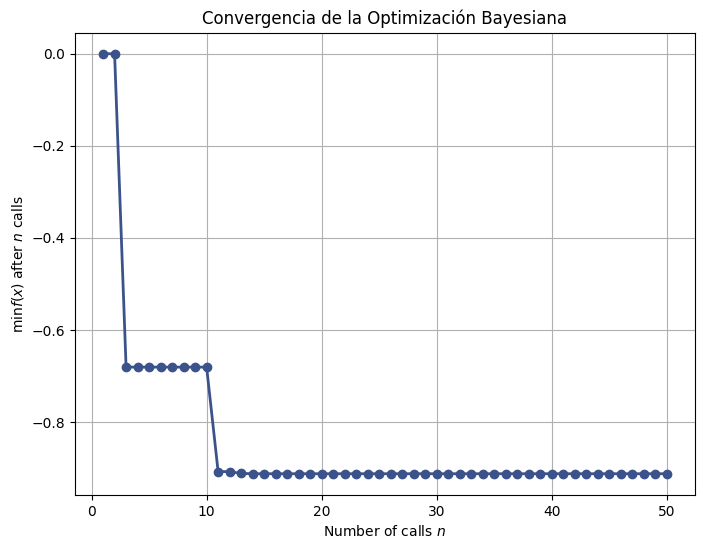

<Figure size 800x600 with 0 Axes>

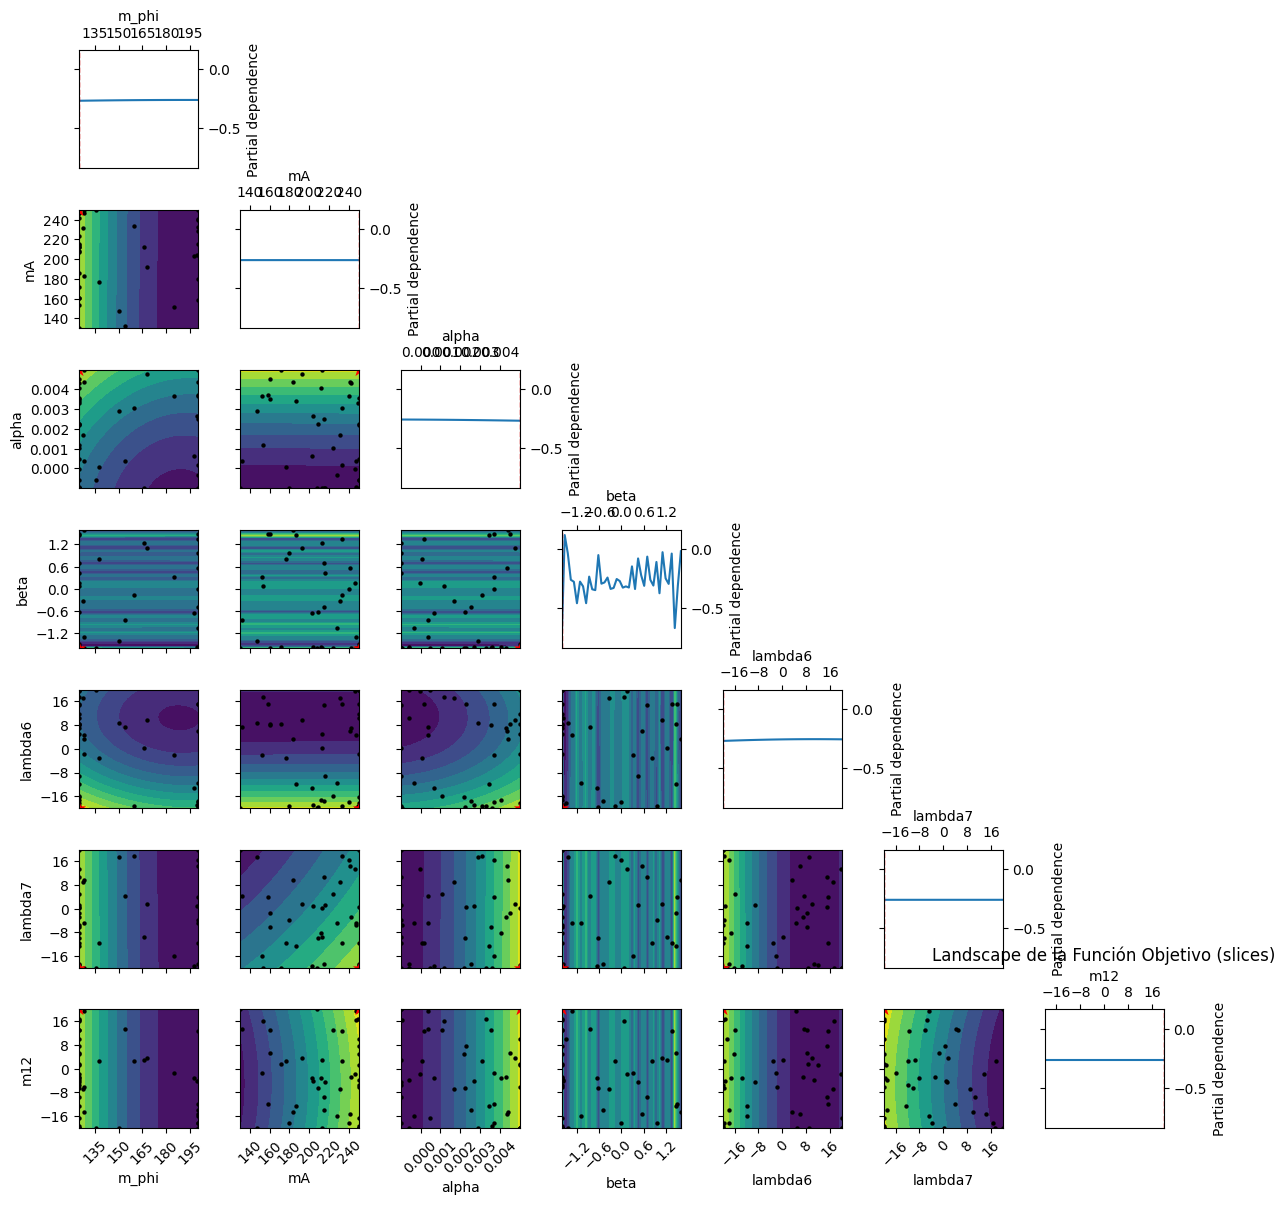

In [21]:
# %% IS6-1: Búsqueda Inteligente con Optimización Bayesiana usando brgaga

from skopt import gp_minimize
from skopt.space import Real
from skopt.plots import plot_convergence, plot_objective
import matplotlib.pyplot as plt

# Definir el espacio de parámetros en el orden sugerido
# double m_phi, double mA, double alpha, double beta, double lambda6, double lambda7, double m12
space = [
    Real(125.0, 200.0, name='m_phi'),
    Real(130.0, 250.0, name='mA'),
    Real(-0.001, 0.005, name='alpha'),
    Real(-1.6, 1.6, name='beta'),
    Real(-20.0, 20.0, name='lambda6'),
    Real(-20.0, 20.0, name='lambda7'),
    Real(-20.0, 20.0, name='m12')
]

def objective(params):
    """
    Función objetivo para la optimización bayesiana.
    Se utiliza la función brgaga para evaluar el Branching Ratio y se retorna
    su negativo para que gp_minimize, que minimiza, actúe maximizando el BR.
    """
    try:
        br_value = brgaga(params)
        print(f"Evaluando con parámetros: {params} => BR: {br_value:.4f}")
    except Exception as e:
        print(f"Error con parámetros {params}: {e}")
        br_value = 0.0  # En caso de error, asignar un valor bajo
    return -br_value

# Ejecutar la optimización bayesiana
n_calls = 50  # Número de evaluaciones, ajustable según necesidades
res = gp_minimize(objective, space, n_calls=n_calls, random_state=42)

# Mejor resultado encontrado
best_params = res.x
best_br = -res.fun  # Se invierte el signo ya que minimizamos el negativo

print("\nOptimización Bayesiana Completada.")
print(f"Mejores parámetros encontrados: {best_params}")
print(f"Mejor Branching Ratio: {best_br:.4f}")

# Gráfico de convergencia
plt.figure(figsize=(8, 6))
plot_convergence(res)
plt.title("Convergencia de la Optimización Bayesiana")
plt.show()

# (Opcional) Visualizar slices del landscape en 2D
plt.figure(figsize=(8, 6))
plot_objective(res)
plt.title("Landscape de la Función Objetivo (slices)")
plt.show()
